データサイズ: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- データの情報 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


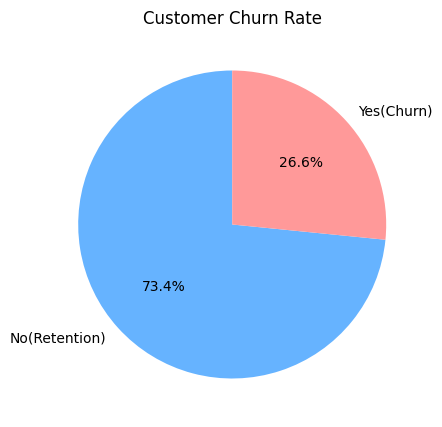

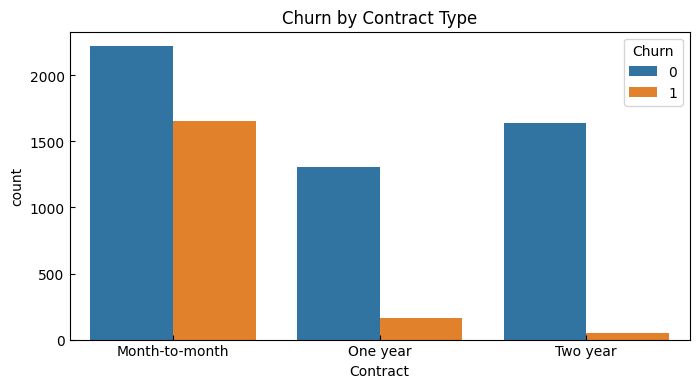

=== ランダムフォレスト 精度評価 ===
Accuracy: 0.7853589196872779
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



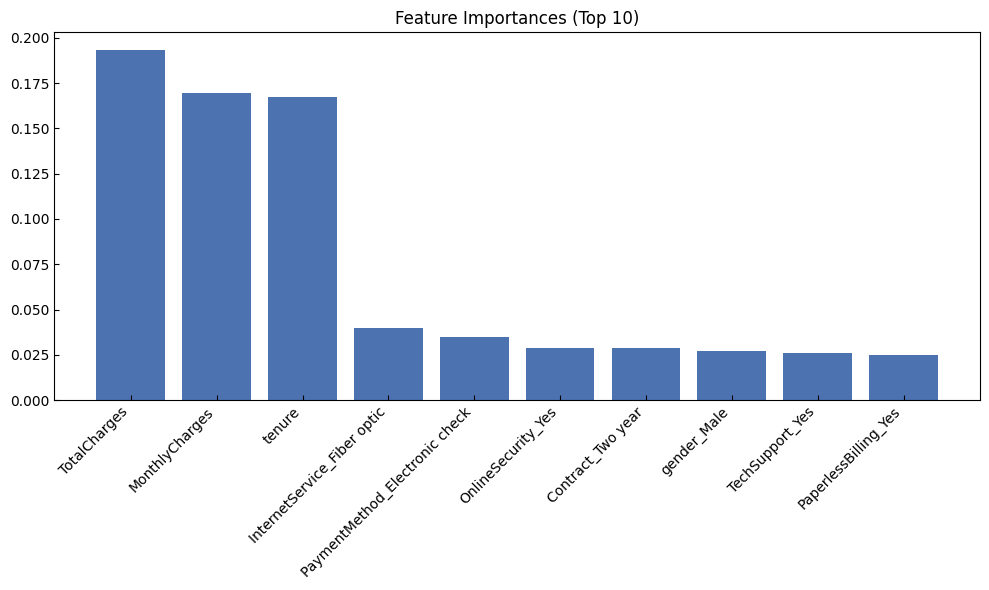

In [1]:
# --- Cell 1: ライブラリのインポートと初期設定 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# matplotlibのグラフ設定（目盛りを内向きに設定）
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'


# --- Cell 2: データの読み込みと初期確認 ---
# データの読み込み
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# データの確認
print("データサイズ:", df.shape)
display(df.head())
print("\n--- データの情報 ---")
df.info()


# --- Cell 3: データの前処理（欠損値処理とエンコーディング） ---
# TotalCharges（総支払い額）が文字列として認識されているため数値に変換し，空白を欠損値(NaN)とする
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 欠損値を含む行（新規顧客など）を削除
df = df.dropna()
print("欠損値の確認:\n", df.isnull().sum()[df.isnull().sum() > 0])

# 予測対象(Churn)を数値（0, 1）に変換
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 分析に寄与しない顧客IDを削除
df = df.drop('customerID', axis=1)

# カテゴリ変数をダミー変数（0,1）に変換 (One-Hot Encoding)
df_encoded = pd.get_dummies(df, drop_first=True)
display(df_encoded.head())


# --- Cell 4: データの可視化（現状把握） ---
# 1. 解約率の円グラフを作成・保存
plt.figure(figsize=(5, 5))
plt.pie(df['Churn'].value_counts(), labels=['No(Retention)', 'Yes(Churn)'],
        autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Customer Churn Rate')
plt.savefig('churn_rate_pie.png', bbox_inches='tight') # レポート貼付用画像
plt.show()

# 2. 契約形態(Contract)別の解約状況を作成・保存
plt.figure(figsize=(8, 4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.savefig('churn_by_contract.png', bbox_inches='tight') # レポート貼付用画像
plt.show()


# --- Cell 5: モデル構築と精度評価 ---
# 特徴量(X)と目的変数(y)の分離
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# 訓練データとテストデータに分割（8:2）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ランダムフォレストモデルの構築・学習
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# テストデータを用いた予測と評価
y_pred = rf_model.predict(X_test)
print("=== ランダムフォレスト 精度評価 ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


# --- Cell 6: 特徴量重要度の抽出と可視化 ---
# 特徴量の重要度を取得し，上位10項目を抽出
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

# 特徴量重要度の棒グラフを作成・保存
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Top 10)")
plt.bar(range(10), importances[indices], align="center", color='#4C72B0')
plt.xticks(range(10), X.columns[indices], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight') # レポート貼付用画像
plt.show()